# Day 2: Pandas Core - Your First Real Dataset
**Dataset:** Titanic (Kaggle)
**Goal:** Replace 20 lines of Python loops with 1 line of Pandas
**Time:** 60 min

## 0. Setup - Install & Download
Run this once. If you already have pandas, it will just skip.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Make plots show up inline
%matplotlib inline

print("Pandas version:", pd.__version__)

# Download Titanic if you don't have it
import pathlib, urllib.request
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
path = pathlib.Path("titanic.csv")
if not path.exists():
    print("Downloading Titanic...")
    urllib.request.urlretrieve(url, path)
    print("Done!")
else:
    print("titanic.csv already exists")


Pandas version: 3.0.5
Done!


## 1. Load and Peek at Data
This is always your first 3 lines with ANY dataset.

In [3]:
df = pd.read_csv("titanic.csv")

# The holy trinity of EDA
print("Shape:", df.shape)  # rows, columns
df.head()


Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()  # What types? Where are nulls?


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()  # Quick stats for numbers


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.describe(include='object')  # Stats for text columns


C:\Users\despi\AppData\Local\Temp\ipykernel_40216\4069281679.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')  # Stats for text columns


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## 2. Filtering - The skill you will use daily

In [7]:
# All female passengers
female = df[df['Sex'] == 'female']
print(f"Female passengers: {len(female)}")
female.head(3)


Female passengers: 314


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


In [9]:
# TODO 1: Find all first-class passengers
first_class = df[df['Pclass'] == 1]
print(f"First class: {len(first_class)}")
first_class.head(3)

# TODO 2: Find all children under 12 who survived
# Hint: (df['Age'] < 12) & (df['Survived'] == 1)
children_survived = df[(df['Age'] < 12) & (df['Survived'] == 1)]
print(f"Children who survived: {len(children_survived)}")
children_survived.head(3)

First class: 216
Children who survived: 39


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
43,44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.0,1,2,SC/Paris 2123,41.5792,NaN,C
58,59,1,2,"West, Miss. Constance Mirium",female,5.0,1,2,C.A. 34651,27.7500,NaN,S


In [10]:
# Sorting - who paid the most?
df.sort_values('Fare', ascending=False).head(5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S


## 3. Handling Missing Data

In [11]:
# Where are the holes?
df.isnull().sum().sort_values(ascending=False)


Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

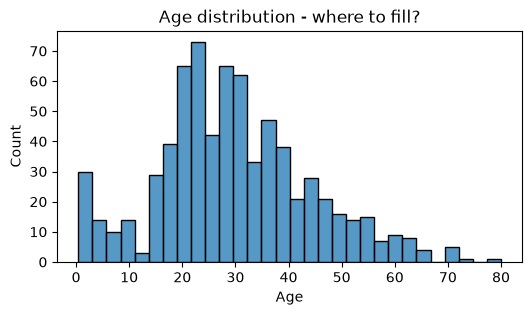

Median age: 28.0
Missing before: 177, after: 0


In [12]:
# Fill or drop? Let's see Age distribution first
plt.figure(figsize=(6,3))
sns.histplot(df['Age'].dropna(), bins=30)
plt.title("Age distribution - where to fill?")
plt.show()

# Fill missing Age with median (better than mean for skewed data)
median_age = df['Age'].median()
df['Age_filled'] = df['Age'].fillna(median_age)

print(f"Median age: {median_age}")
print(f"Missing before: {df['Age'].isnull().sum()}, after: {df['Age_filled'].isnull().sum()}")


## 4. GroupBy - Your superpower for business questions

In [13]:
# Survival rate by sex - the most famous Titanic insight
df.groupby('Sex')['Survived'].mean()
# .mean() on 0/1 column = survival rate


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [14]:
# TODO: Survival rate by class
df.groupby('Pclass')['Survived'].mean()


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [15]:
# Two dimensions: Sex AND Class
df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
# Reading: Female 1st class = 97% survived, Male 3rd class = 14%


Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


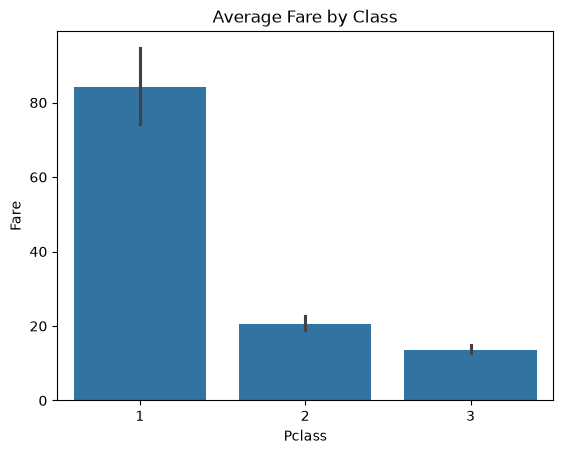

In [16]:
# Average fare by class
sns.barplot(data=df, x='Pclass', y='Fare')
plt.title("Average Fare by Class")
plt.show()


## 5. Creating New Columns (Feature Engineering Lite)

In [17]:
# Family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Is alone?
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Age group
def age_group(age):
    if age < 12:
        return 'Child'
    elif age < 18:
        return 'Teen'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

df['AgeGroup'] = df['Age_filled'].apply(age_group)

df[['Age', 'Age_filled', 'AgeGroup', 'FamilySize', 'IsAlone']].head()


,Age,Age_filled,AgeGroup,FamilySize,IsAlone
0,22.0,22.0,Adult,2,0
1,38.0,38.0,Adult,2,0
2,26.0,26.0,Adult,1,1
3,35.0,35.0,Adult,2,0
4,35.0,35.0,Adult,1,1


In [18]:
df.groupby('AgeGroup')['Survived'].mean()


AgeGroup
Adult     0.364362
Child     0.573529
Senior    0.269231
Teen      0.488889
Name: Survived, dtype: float64

## 6. CHALLENGE - Your 5 Insights (20 min)
Write these in markdown below your code - this is what hiring managers read.

Overall survival: 38.4%


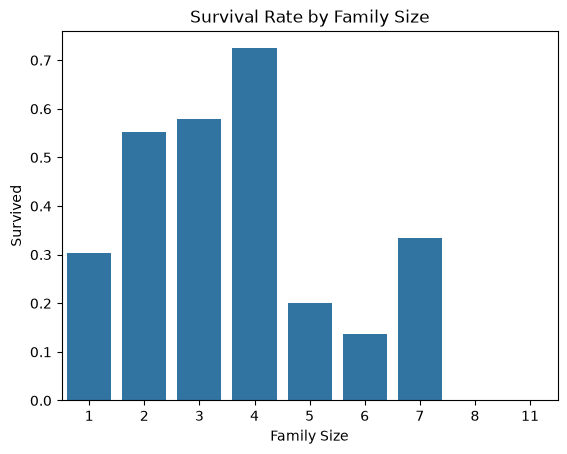

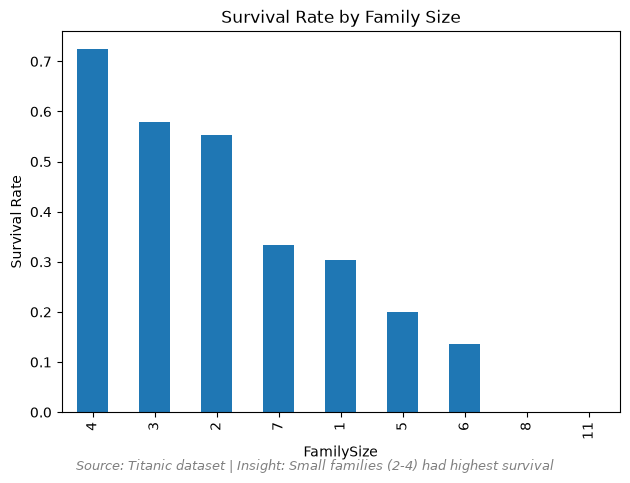

,Survived,Fare
0,0,22.117887
1,1,48.395408


In [34]:
# TODO: Answer these with code and write 1 sentence insight for each
# 1. What % of passengers survived?
print(f"Overall survival: {df['Survived'].mean()*100:.1f}%")

# 2. Which age group had highest survival?
# Your code here
df.groupby('AgeGroup')['Survived'].mean().sort_values(ascending = False).head(1)

# 3. Did family size help?
survival_by_famsize = df.groupby('FamilySize')['Survived'].mean().reset_index().sort_values('Survived', ascending=False)
sns.barplot(data=survival_by_famsize, x='FamilySize', y='Survived')
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.show()

survival_by_famsize = df.groupby('FamilySize')['Survived'].mean().sort_values(ascending=False)
survival_by_famsize.plot(kind='bar')
plt.title("Survival Rate by Family Size")
plt.ylabel("Survival Rate")
# Add footnote
plt.figtext(0.5, 0.01, "Source: Titanic dataset | Insight: Small families (2-4) had highest survival", 
            ha="center", fontsize=9, style='italic', color='gray')

plt.tight_layout()  # keeps footnote from getting cut off
plt.show()

# 4. What was average fare for survivors vs non-survivors?
df.groupby('Survived')['Fare'].mean().reset_index()

# 5. Your own question!


### Write your insights here (edit this cell):
**Insight 1:** Overall survival was XX%
**Insight 2:** Women survived at XX% vs men at XX%
**Insight 3:** ...
**Insight 4:** ...
**Insight 5:** ...

### Done Checklist
- [ ] Found 5 insights with code
- [ ] Created 2 new columns
- [ ] Made 1 chart
- [ ] Saved as `day-02-pandas-titanic.ipynb`

**Tomorrow Day 3:** Filtering & Cleaning Netflix dataset - the messy one.